# Aggregating impact projections to administrative units

This notebook takes climate impact projections at impact region level
and aggregates them to Colombia's departments (ADM1). It uses a small
sample of real Monte Carlo mortality projections: two batches, one
climate model. The full output has hundreds of draws and dozens of
models, so treat the numbers here as a demonstration, not results.

You need the `cil_regionalization` package with the `[netcdf]` extra,
`matplotlib` for the maps, and a network connection. The weights come
from the published Zenodo records. The projection sample is committed
next to this notebook. Run it from this directory.

In [1]:
from pathlib import Path

import pandas as pd

import cil_regionalization as cilreg

DATA = Path("data")
DATA_VERSION = "world-combo-201710"  # the impact region version of the sample
LEAF_DIR = DATA / "montecarlo" / "batch0" / "rcp85" / "GFDL-ESM2G" / "low" / "SSP3"

## Fetch the weights

`fetch_weights` downloads a weight file from Zenodo, checks it against
the checksum recorded when it was built, and caches it. Monetized
damages are dollar totals, so they need the `per_source` weights: each
region's total gets split between the departments it touches.

In [2]:
weights = cilreg.fetch_weights("gadm20-adm1-per-source")
print(len(weights.frame), "rows,", weights.normalization, ",", weights.source_version)

25236 rows, per_source , world-combo-201710


## Aggregate one draw

The weight file covers the whole world, but this sample only has
Colombia. `restrict_to_sources` tells `apply_weights` which impact
regions are included. The department totals have to add back up to the
region totals, and `apply_weights` checks that; the two sums printed
below are the same number.

In [3]:
damages = cilreg.read_netcdf_leaf(
    LEAF_DIR / "mortality_damages_IR_batch.nc4",
    variables=["total_damages"], region_dim="region", region_col="hierid",
    kind="extensive",
)
col_regions = {(h,) for h in damages["hierid"].unique()}

adm1 = cilreg.apply_weights(
    weights, damages,
    kind="extensive", weight="pop", value_col="total_damages",
    data_version=DATA_VERSION, restrict_to_sources=col_regions,
).frame

d99 = adm1[adm1["year"] == 2099]
print(f"departments: {d99['ID_1'].nunique()}")
print(f"sum over departments:    {d99['total_damages'].sum():.6e}")
print(f"sum over impact regions: {damages.query('year == 2099')['total_damages'].sum():.6e}")

departments: 32
sum over departments:    -1.774214e+11
sum over impact regions: -1.774214e+11


## Map the result

The geometry file `data/col_adm1_plot.parquet` is only used to make
the map. It is the impact region shapes (Climate Impact Lab geometry,
published on Zenodo) merged into departments and simplified.

Negative values mean fewer deaths: under this cool climate model draw,
warming avoids more cold deaths than it adds heat deaths.

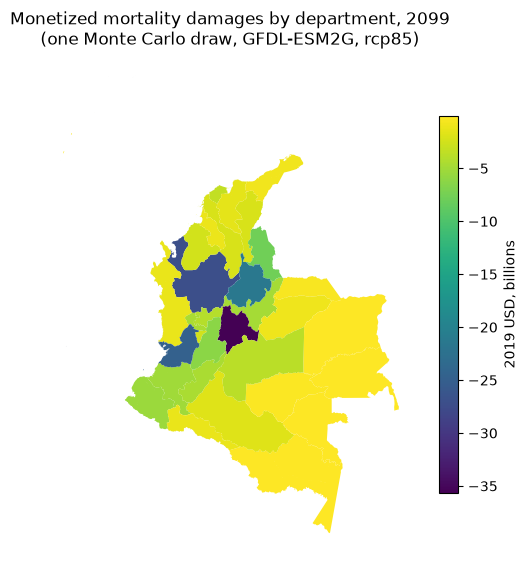

In [4]:
import geopandas as gpd

shapes = gpd.read_parquet(DATA / "col_adm1_plot.parquet")
m = shapes.merge(d99, on=["ISO", "ID_1"])
m["billions"] = m["total_damages"] / 1e9
ax = m.plot(column="billions", legend=True, cmap="viridis", figsize=(6, 7),
            legend_kwds={"label": "2019 USD, billions", "shrink": 0.7})
ax.set_title("Monetized mortality damages by department, 2099\n(one Monte Carlo draw, GFDL-ESM2G, rcp85)")
ax.set_axis_off()

## Percent of GDP

Dollar totals mostly track population: big departments dominate. To
compare departments, divide by GDP. That is the third variable kind,
`ratio`: the damages and the GDP are each aggregated as totals, and
the division happens after, per department. Dividing first and
averaging the ratios would give a different, wrong answer.

The GDP here comes embedded in the same projection files as the
damages, so both sides of the ratio use the same socioeconomic
version. This is also the form the published Climate Impact Lab tables
use.

In [5]:
both = cilreg.read_netcdf_leaf(
    LEAF_DIR / "mortality_damages_IR_batch.nc4",
    variables=["total_damages", "gdp"], region_dim="region", region_col="hierid",
)

pct = cilreg.apply_weights(
    weights, both,
    kind="ratio", weight="pop",
    value_col="total_damages", denominator_col="gdp",
    data_version=DATA_VERSION, restrict_to_sources=col_regions,
).frame

p99 = pct[pct["year"] == 2099].copy()
p99["pct_gdp"] = p99["total_damages"] * 100
p99[["ISO", "ID_1", "pct_gdp"]].sort_values("pct_gdp").head(5)

,ISO,ID_1,pct_gdp
2429,COL,27,-18.232679
1979,COL,22,-16.466663
2699,COL,30,-15.017105
2609,COL,29,-13.061152
1799,COL,20,-13.037557


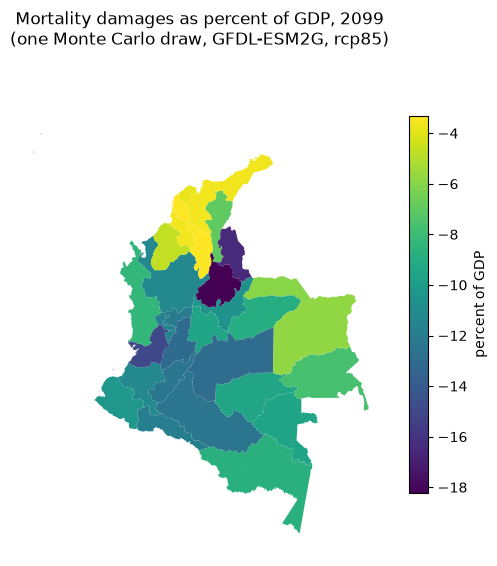

In [6]:
mp = shapes.merge(p99, on=["ISO", "ID_1"])
ax = mp.plot(column="pct_gdp", legend=True, cmap="viridis", figsize=(6, 7),
             legend_kwds={"label": "percent of GDP", "shrink": 0.7})
ax.set_title("Mortality damages as percent of GDP, 2099\n(one Monte Carlo draw, GFDL-ESM2G, rcp85)")
ax.set_axis_off()

## Calculate statistics

Each Monte Carlo draw is aggregated first. The statistics are then
calculated across the aggregated draws. This order matters: summing
per-region quantiles would treat every region as having its worst draw
at the same time, which overstates the tails. With only two draws the
quantiles below just show the mechanics.

In [7]:
frames = []
for batch in ("batch0", "batch1"):
    leaf = DATA / "montecarlo" / batch / "rcp85" / "GFDL-ESM2G" / "low" / "SSP3" / "mortality_damages_IR_batch.nc4"
    data = cilreg.read_netcdf_leaf(leaf, variables=["total_damages"],
                                   region_dim="region", region_col="hierid",
                                   kind="extensive")
    applied = cilreg.apply_weights(
        weights, data, kind="extensive", weight="pop",
        value_col="total_damages", data_version=DATA_VERSION,
        restrict_to_sources=col_regions,
    )
    frames.append(applied.frame.assign(batch=batch))

stats = cilreg.summarize_samples(
    pd.concat(frames, ignore_index=True),
    sample_dims=["batch"], time_col="year", window=(2080, 2099),
    value_col="total_damages", quantiles=[0.05, 0.5, 0.95],
)
stats[stats["ID_1"] == 1]

,ISO,ID_1,statistic,total_damages
0,COL,1,mean,-4.022969e+07
32,COL,1,q05,-1.483635e+08
64,COL,1,q50,-4.022969e+07
96,COL,1,q95,6.790414e+07


## Other variable types

Rates, like deaths per person per year, are averages rather than
totals. They use the `per_destination` weights, which average over the
regions inside each department. The script next to this notebook,
`run_example.py`, runs both kinds at ADM1 and ADM2 from the command
line, and has an `--offline` mode that uses committed weight slices
instead of fetching. The README in this directory shows its full
output.